# **Credit Card Fraud Detection**

**Key design choice:** instead of predicting a hard `0`/`1` label, this pipeline outputs the probability that a transaction is fraudulent - e.g. `87.3% chance of fraud` - and routes each transaction into a risk tier for a downstream decision system.

**Core challenge:** severely imbalanced data. Accuracy is useless here - a model that always predicts "Normal" still scores 99.83%. I use AUC-PR (Precision-Recall AUC) as my primary metric throughout, since AUC-ROC can look deceptively good on data this skewed.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb
import xgboost as xgb

from sklearn.frozen import FrozenEstimator

In [20]:
df = pd.read_csv('creditcard.csv')

# creditcard.csv has ~1081 duplicate rows on Kaggle. If I don't drop them,
# the same transaction can end up split across train and test/val, which
# leaks information and distorts both my evaluation scores and the
# stability I see across CV folds.
print(f"Duplicates before dedup: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape       : {df.shape}")
print(f"Fraud cases : {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%)")
print(f"Missing     : {df.isnull().sum().sum()}")

Duplicates before dedup: 1081
Shape       : (283726, 31)
Fraud cases : 473 (0.167%)
Missing     : 0


### **EDA**

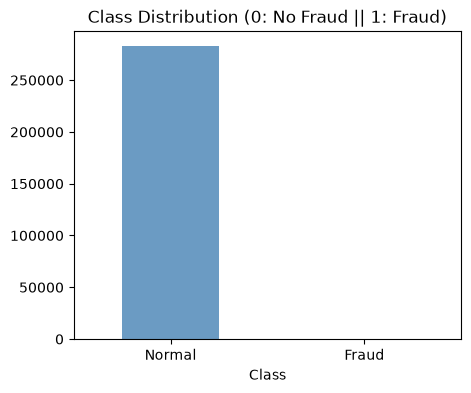

In [21]:
df['Class'].value_counts().sort_index().plot(
    kind='bar', color=['steelblue', 'red'], alpha=0.8, figsize=(5,4))
plt.title('Class Distribution (0: No Fraud || 1: Fraud)')
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.show()

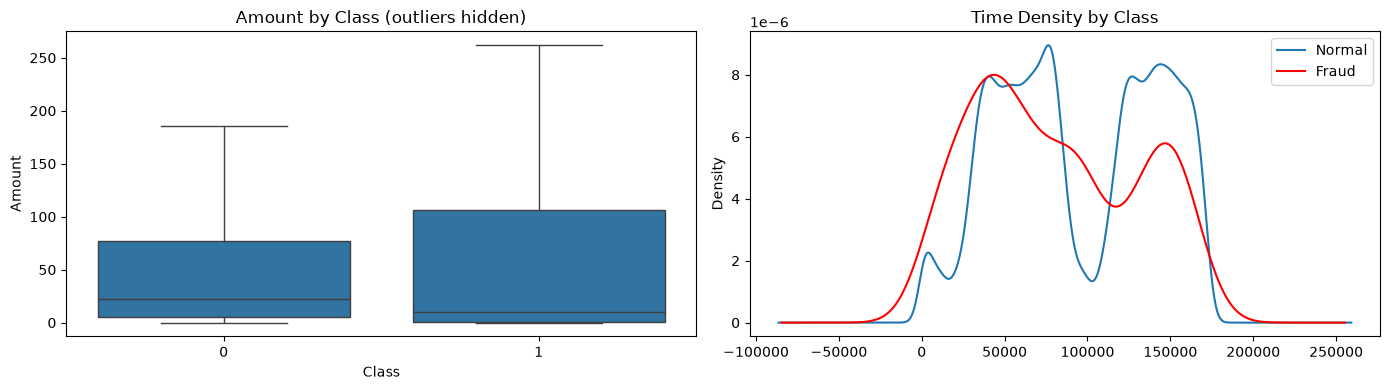

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], showfliers=False)
axes[0].set_title('Amount by Class (outliers hidden)')

df.loc[df['Class']==0, 'Time'].plot(kind='kde', ax=axes[1], label='Normal')
df.loc[df['Class']==1, 'Time'].plot(kind='kde', ax=axes[1], label='Fraud', color='red')
axes[1].set_title('Time Density by Class')
axes[1].legend()
plt.tight_layout()
plt.show()

**Observation:** fraudulent transactions are spread more evenly across the two-day window than genuine ones - genuine transactions dip overnight following normal human shopping patterns, while fraud doesn't. `Time` on its own isn't a strong feature, but this pattern is a useful sanity check that the data behaves the way I'd expect fraud to behave.

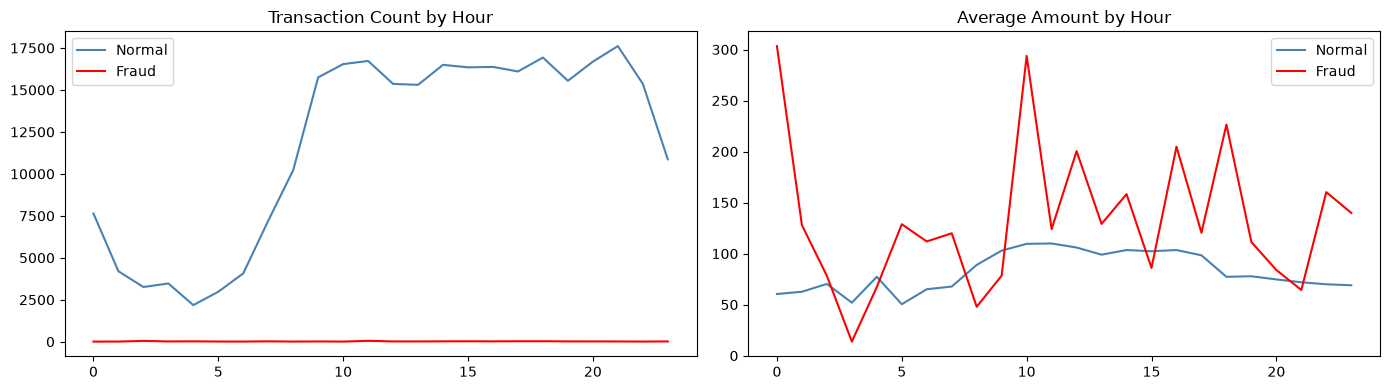

In [23]:
df['Hour'] = (df['Time'] // 3600) % 24

hourly = df.groupby(['Hour', 'Class'])['Amount'].agg(['count', 'mean', 'sum']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cls, color, label in [(0, 'steelblue', 'Normal'), (1, 'red', 'Fraud')]:
    sub = hourly[hourly['Class'] == cls]
    axes[0].plot(sub['Hour'], sub['count'], color=color, label=label)
    axes[1].plot(sub['Hour'], sub['mean'], color=color, label=label)
axes[0].set_title('Transaction Count by Hour'); axes[0].legend()
axes[1].set_title('Average Amount by Hour'); axes[1].legend()
plt.tight_layout()
plt.show()

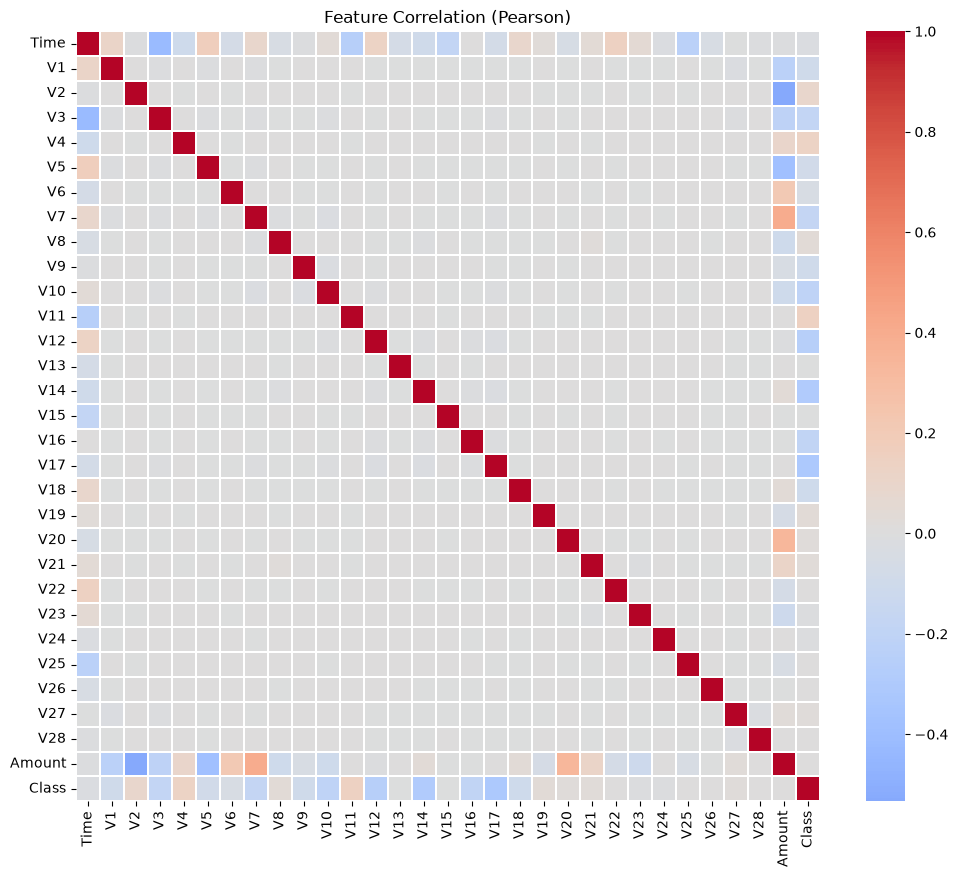

In [24]:
plt.figure(figsize=(12, 10))
corr = df.drop(columns=['Hour']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Feature Correlation (Pearson)')
plt.show()

V1 - V28 are already PCA components so they're essentially uncorrelated with each other, as expected. What's worth a second look is how a few of them correlate with `Amount`/`Time`, and (more importantly) how they relate to `Class`.

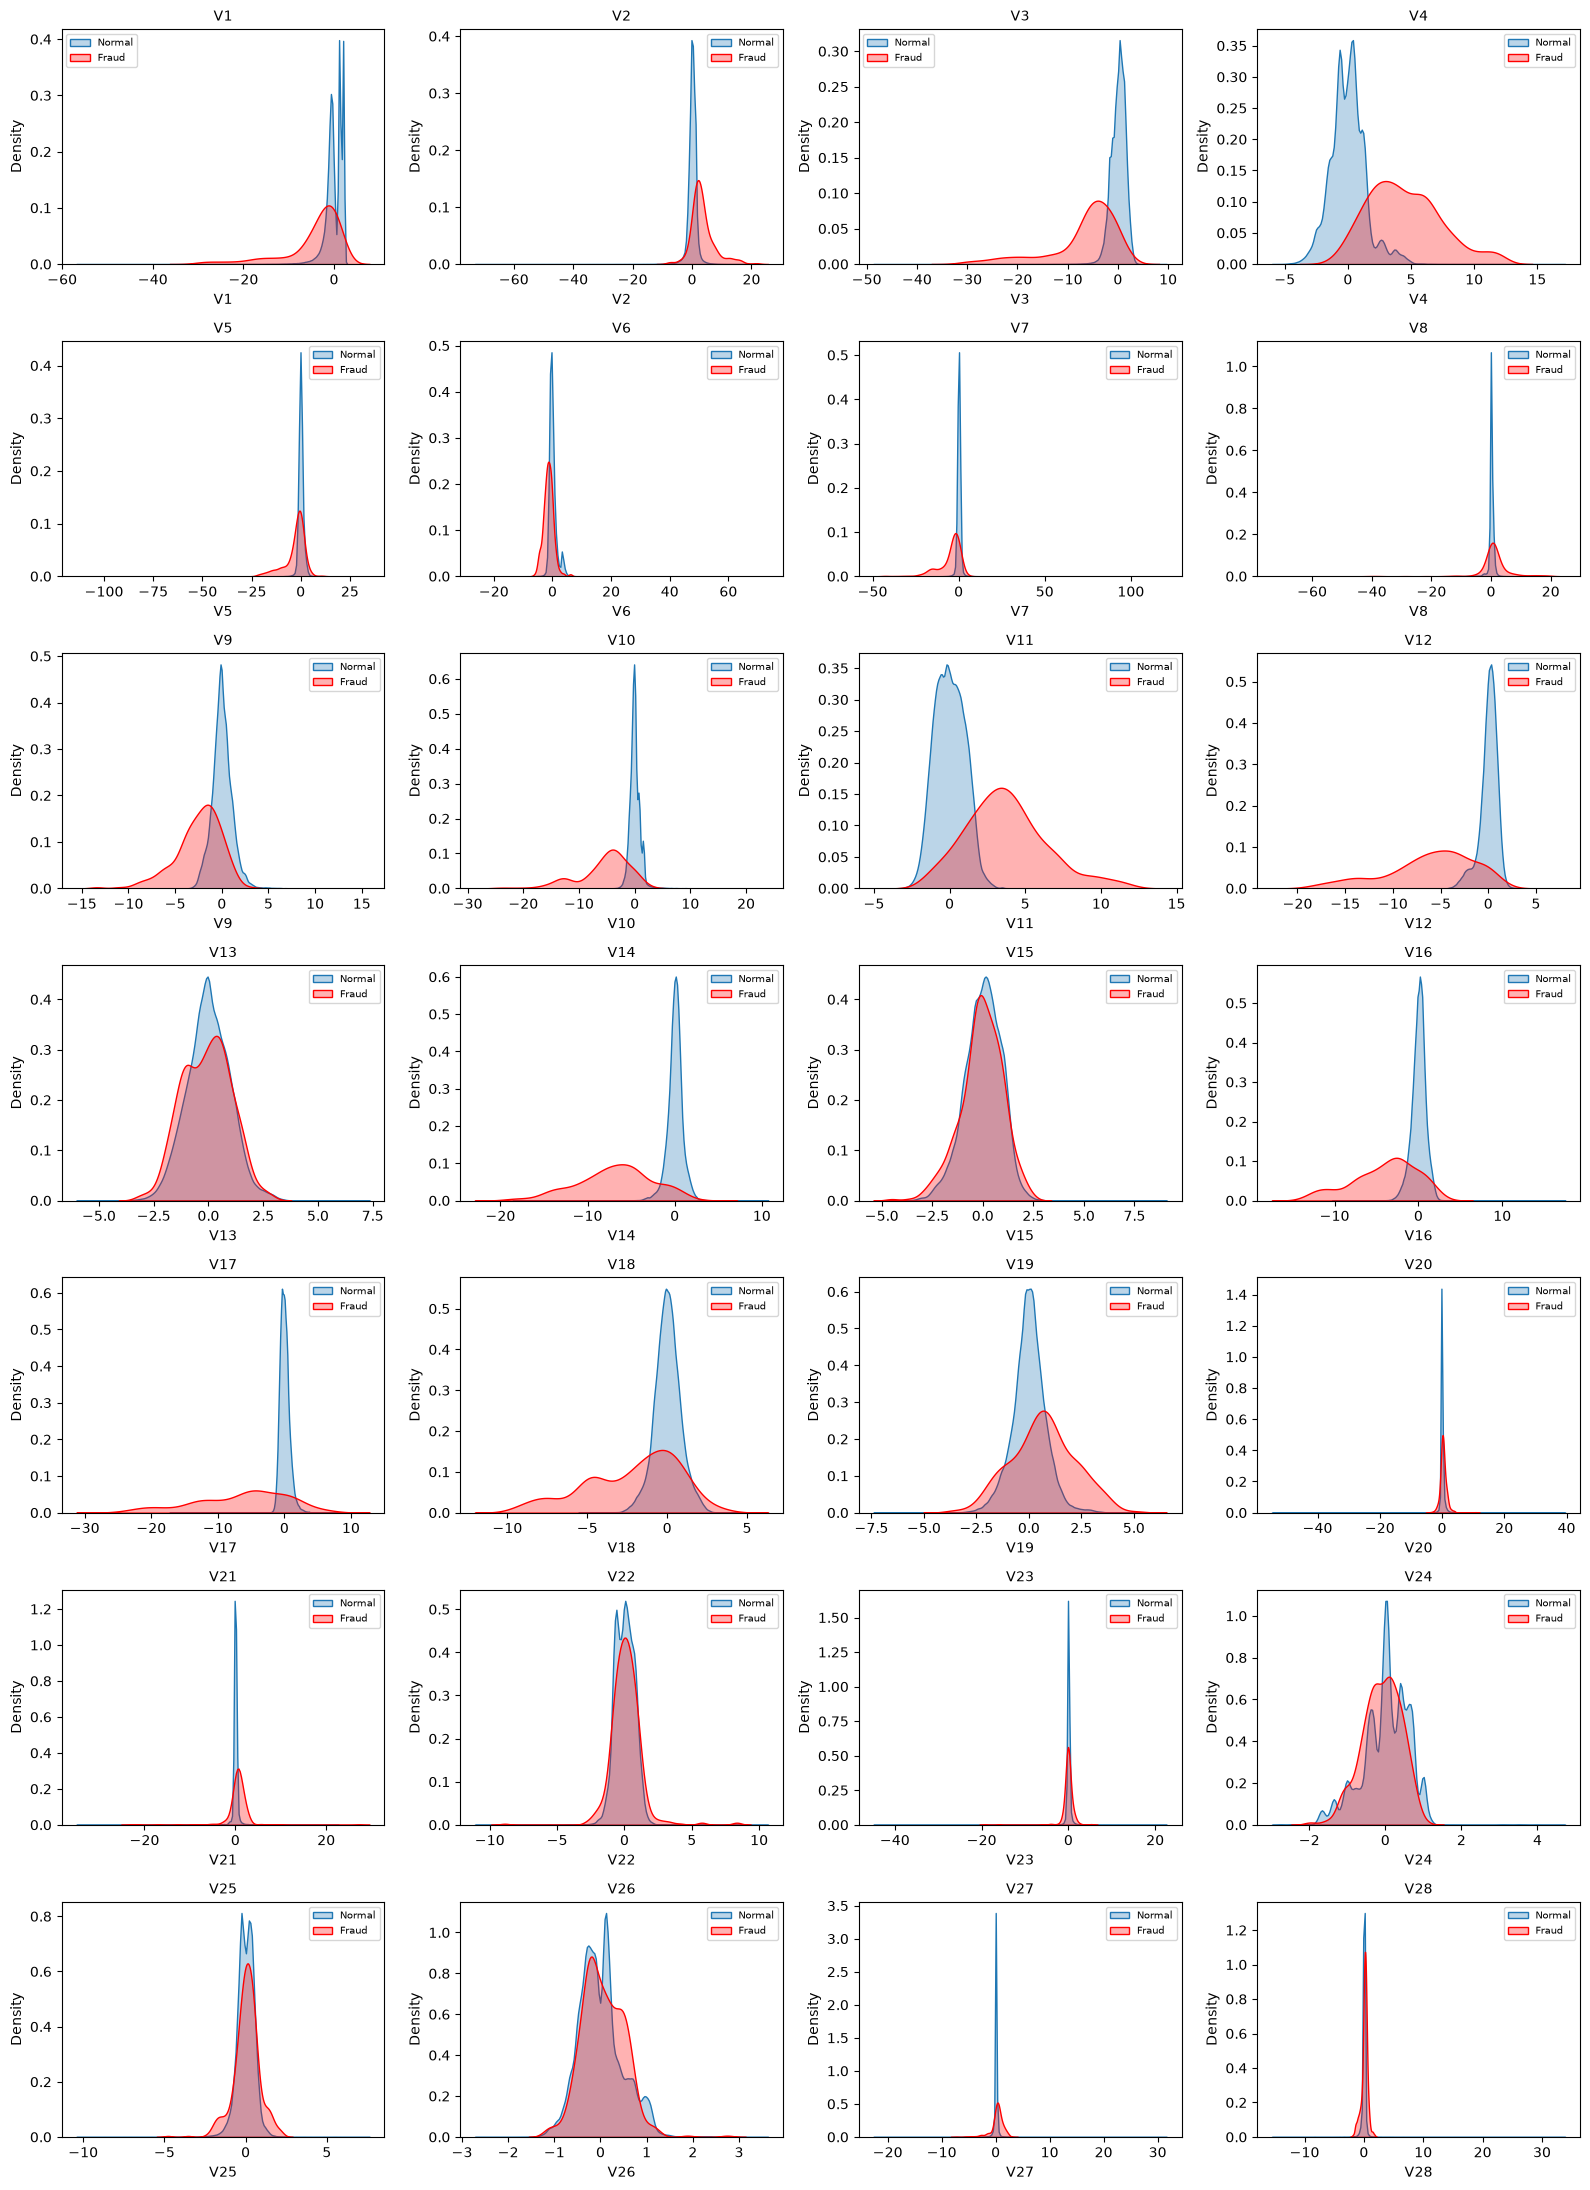

In [25]:
v_features = [c for c in df.columns if c.startswith('V')]

fig, axes = plt.subplots(7, 4, figsize=(16, 22))
axes = axes.flatten()
for i, feature in enumerate(v_features):
    sns.kdeplot(df.loc[df['Class']==0, feature], ax=axes[i], label='Normal', fill=True, alpha=0.3)
    sns.kdeplot(df.loc[df['Class']==1, feature], ax=axes[i], label='Fraud', fill=True, alpha=0.3, color='red')
    axes[i].set_title(feature, fontsize=10)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

This is the fastest way for me to spot which features actually separate the two classes before I train anything

Features where the two curves are clearly separated (typically V4, V11, V12, V14, V17) are strong signals for the classifier; features where the curves nearly overlap (typically V13, V15, V22, V23, V25, V26) contribute little. I don't drop them manually - LightGBM handles low-signal features fine on its own - but it's useful context for interpreting SHAP results later.

### **Feature Engineering**

In [26]:
df['Amount_log'] = np.log1p(df['Amount'])
# 'Hour' was already created and I keep it as a feature.

X = df.drop(['Class', 'Time', 'Amount'], axis=1)
y = df['Class']

print(f"Total features: {X.shape[1]}")
print(X.columns.tolist())

Total features: 30
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Amount_log']


### **Model**

In [27]:
#I hate every second of this

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test  : {X_test.shape}  | Fraud: {y_test.sum()}  ({y_test.mean()*100:.3f}%)")

scaler = StandardScaler()
cols_to_scale = ['Amount_log', 'Hour']

X_train = X_train.copy()
X_test  = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])  # never fit on test

class_weights    = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
scale_pos_weight = class_weights[1] / class_weights[0]
print(f"\nscale_pos_weight: {scale_pos_weight:.1f}")

Train : (226980, 30) | Fraud: 378 (0.167%)
Test  : (56746, 30)  | Fraud: 95  (0.167%)

scale_pos_weight: 599.5


In [29]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        n_jobs=-1, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr', n_jobs=-1, random_state=42),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=4, num_leaves=15,
        min_child_samples=50, reg_alpha=0.5, reg_lambda=1.0,
        subsample=0.7, colsample_bytree=0.7,
        scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, verbose=-1),
}

cv_compare = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

print(f"{'Model':15s} {'Val AUC-PR (mean ± std)':>28s}")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=cv_compare,
        scoring='average_precision', n_jobs=-1
    )
    print(f"{name:15s} {scores.mean():>18.4f} ± {scores.std():.4f}")

Model                Val AUC-PR (mean ± std)
---------------------------------------------
RandomForest                0.8402 ± 0.0338
XGBoost                     0.8347 ± 0.0297
LightGBM                    0.6445 ± 0.1852


XGBoost have the best result so I will choose it

In [30]:
#Diagnostic - Fraud Count per Fold
cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (tr_idx, val_idx) in enumerate(cv_check.split(X_train, y_train)):
    print(f"Fold {i+1}: train fraud={y_train.iloc[tr_idx].sum():>3}  "
          f"val fraud={y_train.iloc[val_idx].sum():>3}")

Fold 1: train fraud=303  val fraud= 75
Fold 2: train fraud=303  val fraud= 75
Fold 3: train fraud=302  val fraud= 76
Fold 4: train fraud=302  val fraud= 76
Fold 5: train fraud=302  val fraud= 76


In [31]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

xgb_cv = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', n_jobs=-1, random_state=42
)

scores = cross_validate(
    xgb_cv, X_train, y_train, cv=cv,
    scoring={'roc_auc': 'roc_auc', 'avg_precision': 'average_precision',
             'brier': 'neg_brier_score'},
    n_jobs=-1, return_train_score=True
)

n_folds = cv.get_n_splits()
print(f"Repeated Stratified K-Fold Results ({n_folds} fits = 5 folds x 5 repeats):")
print("-" * 60)
print(f"AUC-PR   val  : {scores['test_avg_precision'].mean():.4f} ± {scores['test_avg_precision'].std():.4f}  ← primary")
print(f"AUC-ROC  val  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
print(f"Brier    val  : {-scores['test_brier'].mean():.5f} ± {scores['test_brier'].std():.5f}  (lower = better)")
print(f"\nAUC-PR   train: {scores['train_avg_precision'].mean():.4f} ± {scores['train_avg_precision'].std():.4f}  ← if much > val → overfitting")
print(f"AUC-ROC  train: {scores['train_roc_auc'].mean():.4f}")

Repeated Stratified K-Fold Results (25 fits = 5 folds x 5 repeats):
------------------------------------------------------------
AUC-PR   val  : 0.8360 ± 0.0283  ← primary
AUC-ROC  val  : 0.9790 ± 0.0094
Brier    val  : 0.00092 ± 0.00013  (lower = better)

AUC-PR   train: 0.9835 ± 0.0040  ← if much > val → overfitting
AUC-ROC  train: 1.0000


In [32]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

xgb_final = xgb.XGBClassifier(
    n_estimators=3000,      
    max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    n_jobs=-1, random_state=42
)

xgb_final.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=200
)

print(f"\nBest iteration : {xgb_final.best_iteration}")
print(f"Best val AUC-PR: {xgb_final.best_score:.4f}")

[0]	validation_0-aucpr:0.44476	validation_1-aucpr:0.41617
[104]	validation_0-aucpr:0.81558	validation_1-aucpr:0.80751

Best iteration : 54
Best val AUC-PR: 0.8230


Brier — Raw       : 0.023271
Brier — Calibrated: 0.000733  (lower = better)


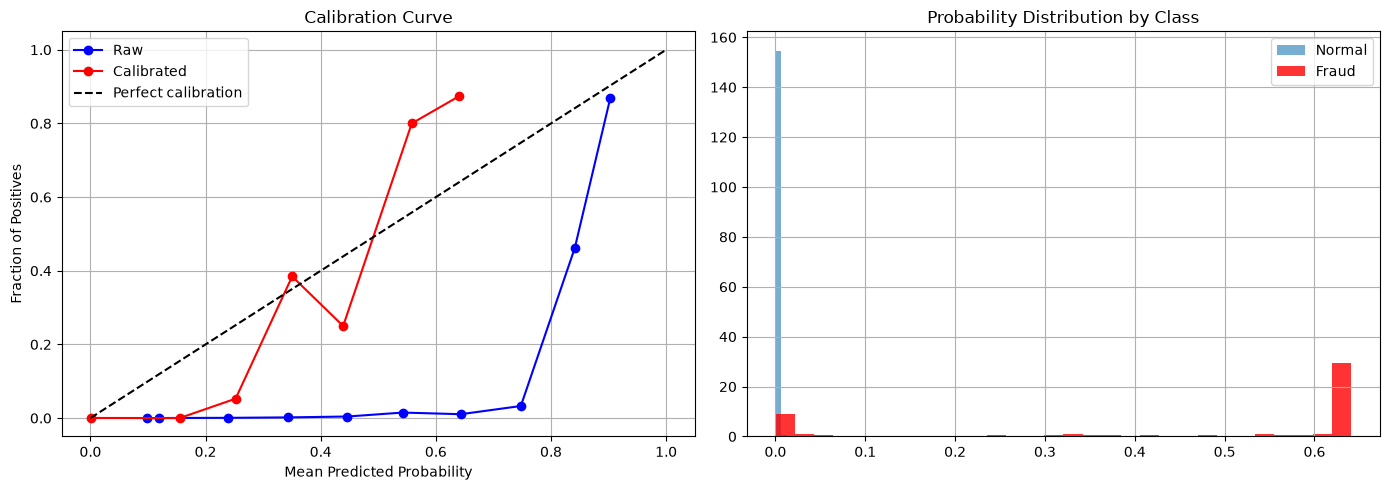

In [34]:
xgb_frozen = FrozenEstimator(xgb_final)
xgb_calibrated = CalibratedClassifierCV(xgb_frozen, method='sigmoid')
xgb_calibrated.fit(X_val, y_val)

raw_probs = xgb_final.predict_proba(X_test)[:, 1]
cal_probs = xgb_calibrated.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for probs, name, color in [(raw_probs, 'Raw', 'blue'), (cal_probs, 'Calibrated', 'red')]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[0].plot(prob_pred, prob_true, marker='o', label=name, color=color)
axes[0].plot([0,1],[0,1],'k--', label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability'); axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve'); axes[0].legend(); axes[0].grid(True)

print(f"Brier — Raw       : {brier_score_loss(y_test, raw_probs):.6f}")
print(f"Brier — Calibrated: {brier_score_loss(y_test, cal_probs):.6f}  (lower = better)")

axes[1].hist(cal_probs[y_test==0], bins=100, alpha=0.6, label='Normal', density=True)
axes[1].hist(cal_probs[y_test==1], bins=30,  alpha=0.8, label='Fraud', color='red', density=True)
axes[1].set_title('Probability Distribution by Class'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

In [35]:
fraud_probs = xgb_calibrated.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df['fraud_probability_pct'] = (fraud_probs * 100).round(2)
results_df['true_label'] = y_test.values
results_df['risk_tier'] = pd.cut(
    fraud_probs, bins=[0, 0.10, 0.40, 0.70, 1.001],
    labels=['Low (<10%)', 'Medium (10–40%)', 'High (40–70%)', 'Critical (>70%)']
)

print(results_df[['fraud_probability_pct', 'risk_tier', 'true_label']]
      .sort_values('fraud_probability_pct', ascending=False).head(20).to_string())

summary = results_df.groupby('risk_tier', observed=True).agg(
    transactions=('true_label', 'count'),
    actual_fraud=('true_label', 'sum'),
    fraud_rate=('true_label', lambda x: f"{x.mean()*100:.1f}%"),
    avg_prob=('fraud_probability_pct', lambda x: f"{x.mean():.1f}%")
).reset_index()
print(summary.to_string(index=False))

        fraud_probability_pct      risk_tier  true_label
211895                  64.09  High (40–70%)           1
83108                   64.06  High (40–70%)           1
46709                   64.06  High (40–70%)           1
9210                    64.06  High (40–70%)           1
150110                  64.06  High (40–70%)           1
15683                   64.06  High (40–70%)           1
8273                    64.06  High (40–70%)           1
115676                  64.06  High (40–70%)           1
119616                  64.06  High (40–70%)           0
142647                  64.06  High (40–70%)           1
191677                  64.06  High (40–70%)           1
18710                   64.06  High (40–70%)           1
79578                   64.06  High (40–70%)           1
162967                  64.06  High (40–70%)           1
150337                  64.06  High (40–70%)           1
93891                   64.06  High (40–70%)           1
10578                   64.06  

### **Final Evaluation**

In [ ]:
auc_roc = roc_auc_score(y_test, fraud_probs)
auc_pr  = average_precision_score(y_test, fraud_probs)
brier   = brier_score_loss(y_test, fraud_probs)

print(f"AUC-PR  : {auc_pr:.4f}  ← primary metric")
print(f"AUC-ROC : {auc_roc:.4f}")
print(f"Brier   : {brier:.6f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
precision, recall, _ = precision_recall_curve(y_test, fraud_probs)
ax1.plot(recall, precision, lw=2, label=f'AP={auc_pr:.3f}')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision'); ax1.legend(); ax1.grid(True)

fpr, tpr, _ = roc_curve(y_test, fraud_probs)
ax2.plot(fpr, tpr, lw=2, label=f'AUC={auc_roc:.3f}')
ax2.plot([0,1],[0,1],'k--')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

### **Feature importance with SHAP (XGBoost)**

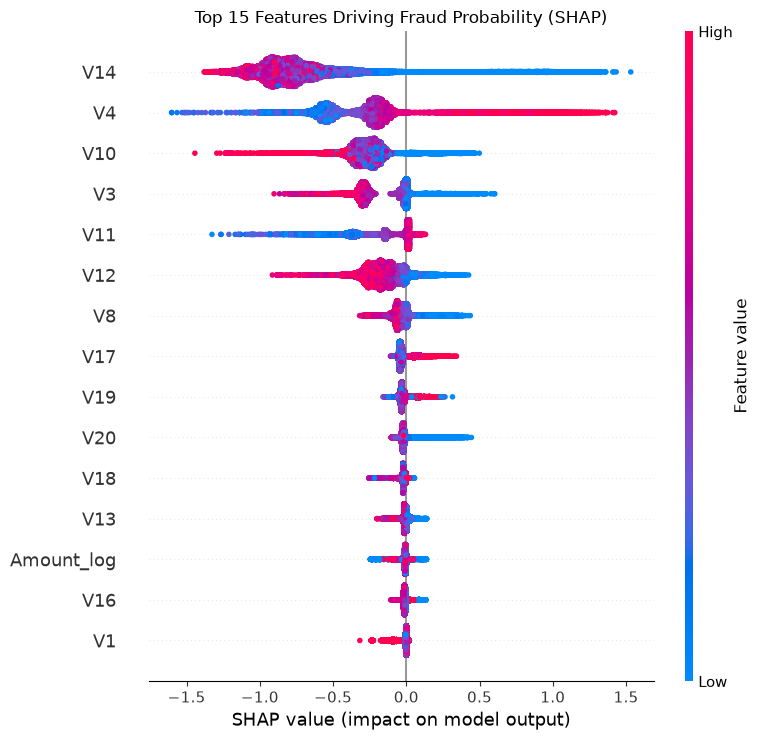

Highest-risk transaction — predicted: 64.09% | true: FRAUD


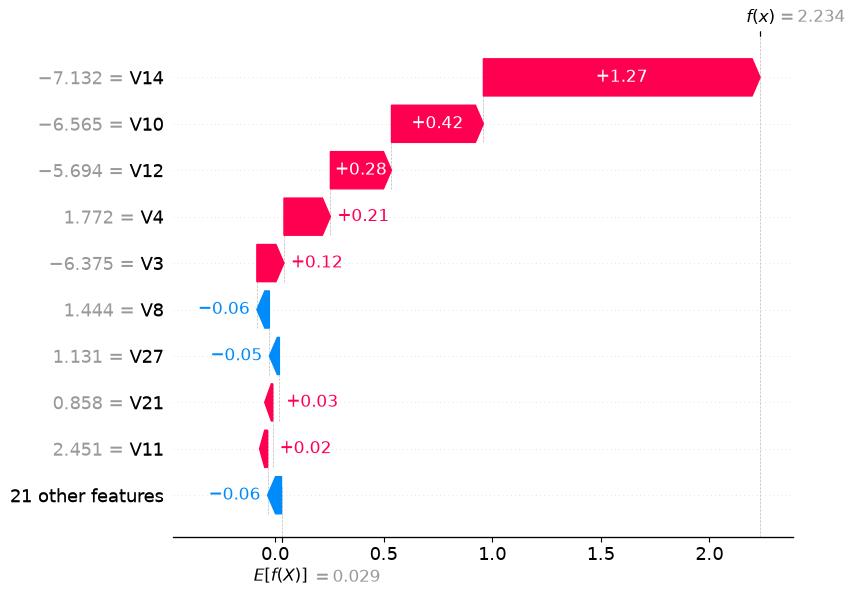

In [36]:
import shap

explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, max_display=15, show=False)
plt.title("Top 15 Features Driving Fraud Probability (SHAP)")
plt.tight_layout()
plt.show()

fraud_idx = np.where(y_test.values == 1)[0]
top_idx   = fraud_idx[np.argmax(fraud_probs[fraud_idx])]
print(f"Highest-risk transaction — predicted: {fraud_probs[top_idx]*100:.2f}% | true: FRAUD")

exp_values = explainer(X_test)   # giữ DataFrame để có tên feature
shap.waterfall_plot(exp_values[top_idx])

### **What to do (risk-based decision rule)**

In [39]:
def assess_transaction(fraud_prob: float) -> dict:
    """Map a fraud probability to a business action.
    Thresholds are adjustable based on the cost of false positives vs false negatives."""
    pct = fraud_prob * 100
    if   pct >= 70: tier, action = "Critical", "BLOCK   - Decline automatically"
    elif pct >= 40: tier, action = "High",     "REVIEW  - Route to fraud analyst"
    elif pct >= 10: tier, action = "Medium",   "MONITOR - Flag for batch review"
    else:           tier, action = "Low",      "PASS    - Approve transaction"
    return {'fraud_probability': f"{pct:.2f}%", 'tier': tier, 'action': action}

print(f"{'Txn #':>6}  {'Fraud Prob':>10}  {'Tier':>8}  {'True Label':>10}  Action")
for i in np.argsort(fraud_probs)[::-1][:15]:
    a = assess_transaction(fraud_probs[i])
    true = "FRAUD ✓" if y_test.values[i] == 1 else "Normal  "
    print(f"{i:>6}  {a['fraud_probability']:>10}  {a['tier']:>8}  {true:>10}  {a['action']}")

 Txn #  Fraud Prob      Tier  True Label  Action
 39333      64.09%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 53773      64.06%      High    Normal    REVIEW  - Route to fraud analyst
   845      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
  1339      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 53293      64.06%      High    Normal    REVIEW  - Route to fraud analyst
 53696      64.06%      High    Normal    REVIEW  - Route to fraud analyst
 51882      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 52699      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 52638      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 52093      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 55158      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 50640      64.06%      High     FRAUD ✓  REVIEW  - Route to fraud analyst
 50775      64.06%      High     FRAUD ✓  REVIEW  -